# 02 · Does the offer work better for some segments? — segment effects (pathmc)

**The decision.** The email clearly lifts spend *on average*. But should we send it
to everyone, or does it really only move **high-value** customers and barely touch
bargain-hunters? If the segments genuinely differ, we write segment-specific send
rules; if the "gap" is just noise, we don't overfit our marketing to it.

We answer with a **structural model** and the **do-operator**: `pathmc` builds the
causal graph, simulates the intervention `do(email=1)` vs `do(email=0)`, and reports
the effect *per segment* with full posterior uncertainty — including a direct read on
**whether the segments truly differ** (the posterior of the interaction term).

Follows the 7-step contract: **question → simulate → identify → estimate → validate
→ decide in € → caveats.**


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import pathmc
from cmp import dgp, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
FIT = dict(draws=300, tune=300, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
SEED = 11; COST = 5.0

## 2 · Simulate a ground truth

Customers are either **high-value** or **low-value** (bargain-hunters). We plant a
real moderation: the email lifts low-value customers by **€3** but high-value ones
by **€12** — a genuine, sizeable gap. `prior_value` also directly drives spend (a
confounder we must include), and there's a background `trend`.


In [2]:
df, true_effect = dgp.segment_customers(n=1200, seed=SEED)
df["is_high"] = (df["prior_value"] == "high").astype(float)
print("TRUE email effect by segment:", true_effect)
df.head()

TRUE email effect by segment: {'low': 3.0, 'high': 12.0}


,email,prior_value,trend,spend,is_high
0,1.0,low,41.244373,25.367947,0.0
1,0.0,low,66.994722,29.696361,0.0
2,1.0,high,44.665532,58.058203,1.0
3,0.0,low,69.381440,16.576403,0.0
4,0.0,low,55.393890,13.033173,0.0


## 3 · Identify — CATE via the do-operator

**Estimand.** The conditional effect
$\tau(x)=\mathbb{E}[Y\mid do(\text{email}{=}1), X{=}x]-\mathbb{E}[Y\mid do(\text{email}{=}0), X{=}x]$.
With a structural equation
$\text{spend}=\beta_0+\beta_1\text{email}+\beta_2\text{value}+\beta_3(\text{email}\cdot\text{value})+\dots$,
the effect is $\tau=\beta_1+\beta_3\cdot\text{value}$ — **heterogeneity lives exactly
in the moderation term $\beta_3$.** Without an interaction, $\tau$ is constant and
`cate()` collapses to `ate()`.

**Identification** is the same unconfoundedness on the email→spend link; the
structural model just makes the adjustment set explicit and lets us query subgroup
effects as functionals of the posterior. `pathmc` confirms the admissible set:


In [3]:
spec = "spend ~ b_email*email + b_val*is_high + b_int*email:is_high + b_tr*trend"
m = pathmc.model(spec, data=df)
print("admissible adjustment set(s) for email→spend:", m.adjustment_sets("email", "spend"))
print("identifiable:", m.is_identifiable("email", "spend"))

admissible adjustment set(s) for email→spend: [set()]
identifiable: True


## 4 · Estimate — fit the structural model

In [4]:
idata = m.fit(random_seed=SEED, progressbar=False, **FIT)   # returns an arviz DataTree
m.effects_summary().round(2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta_spend, sigma_spend]
Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%
name,,,,
b_email,2.94,0.45,2.07,3.74
b_val,18.36,0.54,17.45,19.44
b_int,8.75,0.73,7.46,10.14
b_tr,0.33,0.02,0.30,0.36


## 5 · Validate — recover the per-segment effects, and test the gap

Query the CATE for each segment and compare to the planted €3 / €12. The decisive
number is the **interaction** $\beta_3$: if its posterior clearly excludes zero, the
segments *really* differ — that's the "is the gap real?" answer.


In [5]:
ate = m.ate("spend", "email", values=(0, 1))
cate_high = m.cate("spend", "email", condition={"is_high": 1.0}, values=(0, 1))
cate_low = m.cate("spend", "email", condition={"is_high": 0.0}, values=(0, 1))

print(f"ATE (pooled)     mean €{ate.mean():5.2f}   {ate.hdi()}")
print(f"CATE low-value   mean €{cate_low.mean():5.2f}   (true €{true_effect['low']:.0f})   {cate_low.hdi()}")
print(f"CATE high-value  mean €{cate_high.mean():5.2f}   (true €{true_effect['high']:.0f})   {cate_high.hdi()}")

# interaction posterior straight from the fitted coefficients
b_int_draws = idata.posterior["beta_spend"].sel(spend_predictors="email:is_high").values.ravel()
p_gap = (b_int_draws > 0).mean()
print(f"\nInteraction β₃  mean €{b_int_draws.mean():.2f}  P(β₃>0) = {p_gap:.3f}  → the gap is "
      + ("REAL" if p_gap > 0.95 else "uncertain"))

ATE (pooled)     mean € 6.29   [5.59535742 6.84201094]
CATE low-value   mean € 2.94   (true €3)   [2.06633319 3.74125241]
CATE high-value  mean €11.69   (true €12)   [10.73527852 12.65524126]

Interaction β₃  mean €8.75  P(β₃>0) = 1.000  → the gap is REAL


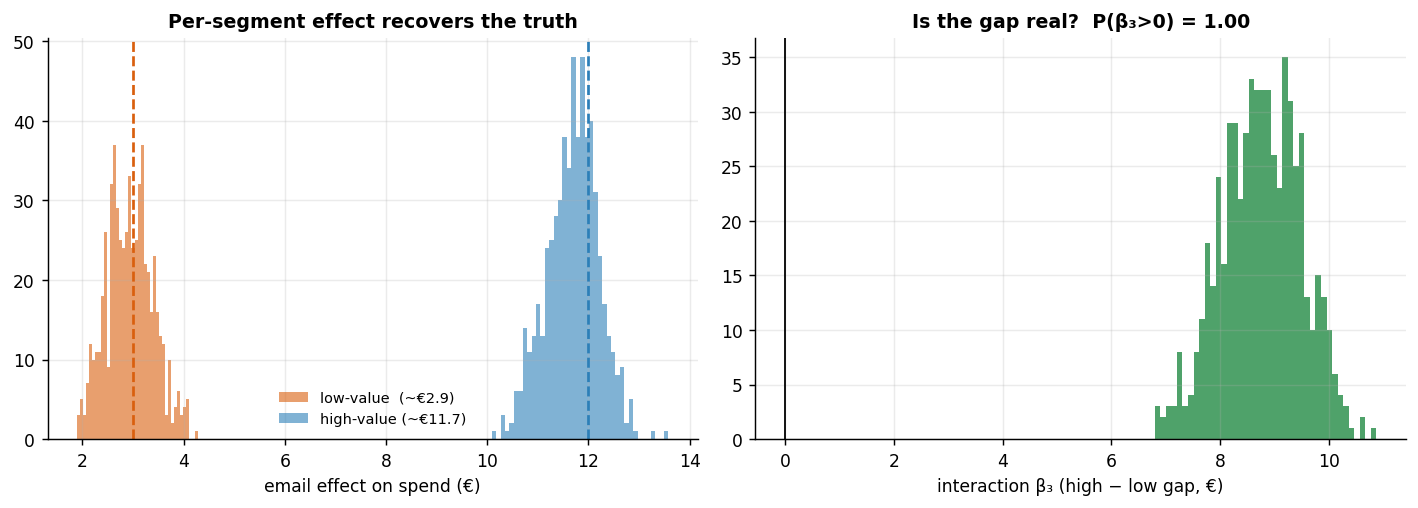

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
lo_d, hi_d = cate_low.draws(), cate_high.draws()
ax[0].hist(lo_d, bins=40, color=plots.ORANGE, alpha=0.6, label=f"low-value  (~€{lo_d.mean():.1f})")
ax[0].hist(hi_d, bins=40, color=plots.BLUE, alpha=0.6, label=f"high-value (~€{hi_d.mean():.1f})")
ax[0].axvline(true_effect["low"], color=plots.ORANGE, ls="--"); ax[0].axvline(true_effect["high"], color=plots.BLUE, ls="--")
ax[0].set_xlabel("email effect on spend (€)"); ax[0].set_title("Per-segment effect recovers the truth")
ax[0].legend(frameon=False, fontsize=8)
ax[1].hist(b_int_draws, bins=40, color=plots.GREEN, alpha=0.8); ax[1].axvline(0, color="k", lw=1)
ax[1].set_xlabel("interaction β₃ (high − low gap, €)")
ax[1].set_title(f"Is the gap real?  P(β₃>0) = {p_gap:.2f}")
fig.tight_layout()

## 6 · Decide, in euros

Turn the per-segment effects into **send rules**. With a €5 contact cost, we ask
per segment: *what's the probability the effect beats cost?* — and target only where
that's high.


In [7]:
for name, cate in [("low-value", cate_low), ("high-value", cate_high)]:
    d = cate.draws()
    p_worth = (d > COST).mean()
    ev = d.mean() - COST
    verdict = "SEND" if p_worth > 0.8 else ("SKIP" if p_worth < 0.5 else "TEST")
    print(f"{name:11s}: effect €{d.mean():5.2f}, net of cost €{ev:+5.2f}, "
          f"P(effect>€{COST:.0f})={p_worth:.2f}  → {verdict}")

low-value  : effect € 2.94, net of cost €-2.06, P(effect>€5)=0.00  → SKIP
high-value : effect €11.69, net of cost €+6.69, P(effect>€5)=1.00  → SEND


## 7 · Caveats

- **Heterogeneity is only as good as the moderator you measured.** If the real
  driver of differential response isn't `is_high` (or a proxy), the interaction
  won't capture it.
- **Interaction ≠ causation of the moderator.** We're not claiming *making* someone
  high-value changes their responsiveness — only that responsiveness *differs* across
  the (pre-existing) segments.
- **Random slopes for many thin segments.** With dozens of small segments, swap the
  single interaction for partially-pooled random slopes ($\beta_{1,g}\sim\mathcal{N}
  (\mu_1,\tau_1^2)$) so noisy segments borrow strength — see notebook 03.
- **Same unconfoundedness caveat as everywhere:** a hidden common cause of email and
  spend would bias every segment effect.
